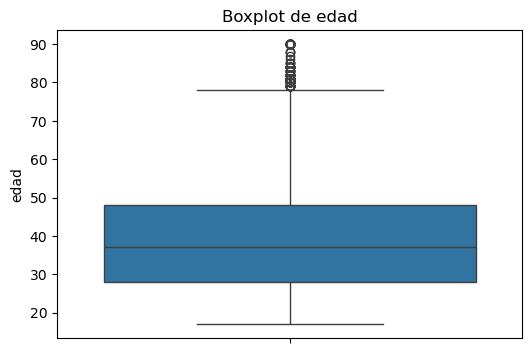

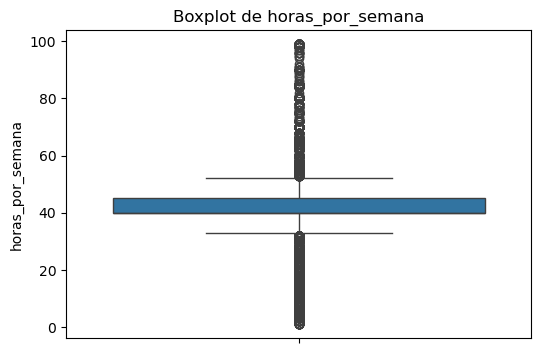

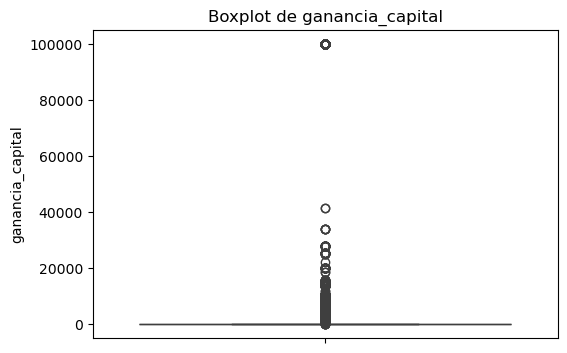

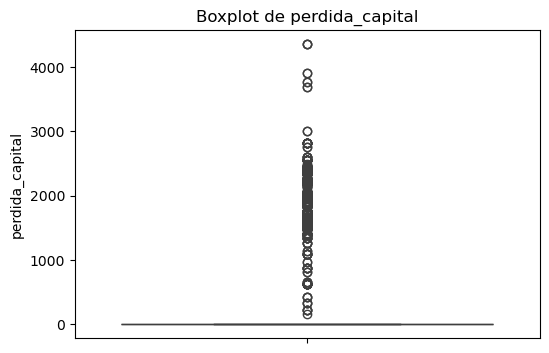

In [ ]:
#codigo de los graficos de las variables para detecter valores atipicos


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

df = pd.read_csv("/home/nahuel/Escritorio/matematica/tp_mate/adult_español.csv")

numericas = ["edad", "horas_por_semana", "ganancia_capital", "perdida_capital"]

for col in numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])  
    plt.title(f"Boxplot de {col}")
    plt.show()



In [ ]:
#codigo de limpieza de datos para eliminar los valores atipicos y los registros con datos desconocidos


import pandas as pd

df = pd.read_csv("/home/nahuel/Escritorio/matematica/tp_mate/adult_español.csv")

df = df.replace("?", "desconocido")

def limpiar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]

df_limpio = limpiar_outliers(df, "horas_por_semana")

df_limpio = df_limpio[df_limpio["edad"] < 80]

df_limpio = df_limpio[(df_limpio["horas_por_semana"] >= 3) & (df_limpio["horas_por_semana"] <= 55)]

df_limpio = df_limpio[df_limpio["ganancia_capital"] <= 250000]

df_limpio = df_limpio[df_limpio["perdida_capital"] <= 3000]

# Guarda el nuevo dataset limpio en un archivo CSV
df_limpio.to_csv("adult_limpio_final.csv", index=False)

print("Filas originales:", len(df))
print("Filas después de limpiar:", len(df_limpio))



Filas originales: 32561
Filas después de limpiar: 23502


In [ ]:
#codigo de normalizacion de los datos para que tengan una media de 0 y una desviacion estandar de 1


import pandas as pd

df = pd.read_csv("adult_limpio_final.csv")

num_cols = ["edad", "horas_por_semana", "ganancia_capital", "perdida_capital"]

# Normalización Z-score manual
for col in num_cols:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

df.to_csv("adult_normalizado.csv", index=False)
print(df.head())


       edad            clase_trabajo  peso_final            educacion  \
0 -0.061756  Autónomo-no-incorporado      164526  Escuela-profesional   
1  1.002552              desconocido      172175            Doctorado   
2  0.593203                  Privado       45363  Escuela-profesional   
3  1.493771                  Privado      317847             Maestría   
4 -1.371673                  Privado      119592           Assoc-acdm   

   educacion_num  estado_civil                  ocupacion          relacion  \
0             15  Nunca-casado   Profesional-especialista  Fuera-de-familia   
1             16  Nunca-casado                desconocido  Fuera-de-familia   
2             15    Divorciado   Profesional-especialista  Fuera-de-familia   
3             14    Divorciado   Ejecutivo-administrativo  Fuera-de-familia   
4             12  Nunca-casado  Manipuladores-limpiadores  Fuera-de-familia   

     raza    sexo  ganancia_capital  perdida_capital  horas_por_semana  \
0  Blanco  H